# Modelado y validacion multiclase para ARMD-AI

## Objetivo de este notebook

En este notebook vamos a construir la fase de modelado para predecir la variable `susceptibility` en tres clases:

- `Susceptible`
- `Intermediate`
- `Resistant`

La idea no es usar un solo modelo a ciegas. Vamos a comparar varios clasificadores para entender:

- cual aprende mejor los patrones del dataset
- cual generaliza mejor sobre datos mas recientes
- cual maneja mejor el desbalance de clases
- cual vale la pena justificar en el informe final

Los modelos que se van a probar son:

- `DummyClassifier`
- `LogisticRegression`
- `KNeighborsClassifier`
- `DecisionTreeClassifier`
- `RandomForestClassifier`
- `XGBClassifier` de XGBoost

Todo el codigo queda comentado y explicado para que puedas entender que hace cada bloque.
El mismo flujo puede correrse sobre una **version base**, una **version ampliada**, una **version multihot_abx**, una **version multihot_comorb** y una **version multihot_abx_comorb** del dataset final de modelado.


## Por que no usamos validacion aleatoria simple

El dataset tiene una columna temporal llamada `order_time_jittered_utc`. Aunque las fechas fueron desidentificadas, conservan el orden relativo de los eventos.

Por eso no conviene mezclar todo aleatoriamente. Si lo hicieramos, el modelo podria entrenar con informacion del futuro y evaluarse con informacion del pasado. Eso produce **data leakage**.

En este notebook haremos una division temporal:

- entrenamiento: registros mas antiguos
- validacion: registros intermedios
- prueba: registros mas recientes

Asi la evaluacion es mas realista.

## Explicacion corta de algunos conceptos que vas a ver

- `Pipeline`: encadena pasos. Por ejemplo, primero limpiar datos y luego entrenar el modelo.
- `ColumnTransformer`: permite aplicar transformaciones distintas a columnas numericas y categoricas.
- `OneHotEncoder`: convierte categorias como `RESPIRATORY` o `BLOOD` en columnas binarias.
- `StandardScaler`: pone variables numericas en una escala comparable. Esto ayuda mucho a `KNN` y a la regresion logistica.
- `SimpleImputer`: rellena valores faltantes de forma controlada. Aqui usaremos mediana para numericas y una etiqueta fija para categoricas.

Importante: esta imputacion es solo para entrenar el modelo. No cambia el analisis exploratorio que ya hiciste.

In [1]:
# Librerias base para tablas, arreglos numericos y graficas.
# Herramientas de scikit-learn para preprocesamiento, modelos y metricas.

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")


## Como leer el codigo de este notebook

Cada bloque sigue una secuencia fija: cargar datos, decidir variables, separar conjuntos, preparar columnas, entrenar modelos y comparar metricas.

Cuando aparezca un metodo importante de libreria, la idea de ese metodo queda explicada en el markdown anterior o en comentarios dentro de la celda.


In [2]:
RUTA_CANDIDATA = Path.cwd().resolve()
if (RUTA_CANDIDATA / "3.DATOS-PROCESADOS").exists():
    RUTA_PROYECTO = RUTA_CANDIDATA
else:
    RUTA_PROYECTO = RUTA_CANDIDATA.parent

RUTA_PROCESADOS = RUTA_PROYECTO / "3.DATOS-PROCESADOS"
RUTA_GRAFICAS = RUTA_PROYECTO / "2.VISUALIZACION-DATOS"
RUTA_MODELADO = RUTA_PROYECTO / "4.MODELADO-Y-VALIDACION"

RUTA_MODELADO.mkdir(parents=True, exist_ok=True)

# Tenemos cinco versiones del dataset final para modelado.
RUTA_DATASET_BASE = RUTA_PROCESADOS / "armd_s_aureus_base_modelado_base.csv"
RUTA_DATASET_AMPLIADA = RUTA_PROCESADOS / "armd_s_aureus_base_modelado_ampliada.csv"
RUTA_DATASET_MULTIHOT_ABX = RUTA_PROCESADOS / "armd_s_aureus_base_modelado_multihot_abx.csv"
RUTA_DATASET_MULTIHOT_COMORB = RUTA_PROCESADOS / "armd_s_aureus_base_modelado_multihot_comorb.csv"
RUTA_DATASET_MULTIHOT_ABX_COMORB = RUTA_PROCESADOS / "armd_s_aureus_base_modelado_multihot_abx_comorb.csv"
RUTA_BASE_LIMPIA = RUTA_PROCESADOS / "armd_s_aureus_base_limpia.csv"

def asegurar_datasets_base_ampliada():
    if RUTA_DATASET_BASE.exists() and RUTA_DATASET_AMPLIADA.exists():
        return
    if not RUTA_BASE_LIMPIA.exists():
        raise FileNotFoundError(f"No existe la base limpia necesaria: {RUTA_BASE_LIMPIA}")

    df_base_limpia = pd.read_csv(RUTA_BASE_LIMPIA, low_memory=False)
    columnas_base = [
        "anon_id",
        "pat_enc_csn_id_coded",
        "order_proc_id_coded",
        "order_time_jittered_utc",
        "antibiotic",
        "culture_description",
        "age",
        "gender",
        "hosp_ward_ICU",
        "hosp_ward_ER",
        "hosp_ward_IP",
        "hosp_ward_OP",
        "susceptibility",
    ]
    columnas_ampliada_extra = ["ordering_mode", "procedure_name", "median_wbc", "median_cr"]
    columnas_ampliada = columnas_base[:-1] + columnas_ampliada_extra + ["susceptibility"]

    faltantes_base = [c for c in columnas_base if c not in df_base_limpia.columns]
    faltantes_ampliada = [c for c in columnas_ampliada if c not in df_base_limpia.columns]
    if faltantes_base:
        raise ValueError(f"Faltan columnas para construir dataset base: {faltantes_base}")
    if faltantes_ampliada:
        raise ValueError(f"Faltan columnas para construir dataset ampliada: {faltantes_ampliada}")

    if not RUTA_DATASET_BASE.exists():
        df_base = df_base_limpia[columnas_base].copy()
        df_base.to_csv(RUTA_DATASET_BASE, index=False)
        print(f"Dataset base reconstruido: {RUTA_DATASET_BASE}")

    if not RUTA_DATASET_AMPLIADA.exists():
        df_ampliada = df_base_limpia[columnas_ampliada].copy()
        df_ampliada.to_csv(RUTA_DATASET_AMPLIADA, index=False)
        print(f"Dataset ampliada reconstruido: {RUTA_DATASET_AMPLIADA}")

asegurar_datasets_base_ampliada()

# Cambia esta variable a "ampliada", "multihot_abx", "multihot_comorb" o "multihot_abx_comorb" si quieres correr otra version del experimento.
VERSION_DATASET = "base"
MAPA_RUTAS_DATASET = {
    "base": RUTA_DATASET_BASE,
    "ampliada": RUTA_DATASET_AMPLIADA,
    "multihot_abx": RUTA_DATASET_MULTIHOT_ABX,
    "multihot_comorb": RUTA_DATASET_MULTIHOT_COMORB,
    "multihot_abx_comorb": RUTA_DATASET_MULTIHOT_ABX_COMORB,
}
if VERSION_DATASET not in MAPA_RUTAS_DATASET:
    raise ValueError(f"VERSION_DATASET no valida: {VERSION_DATASET}")
RUTA_DATASET = MAPA_RUTAS_DATASET[VERSION_DATASET]

print("Version seleccionada:", VERSION_DATASET)
print("Ruta del dataset:", RUTA_DATASET)


Dataset base reconstruido: D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\3.DATOS-PROCESADOS\armd_s_aureus_base_modelado_base.csv
Dataset ampliada reconstruido: D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\3.DATOS-PROCESADOS\armd_s_aureus_base_modelado_ampliada.csv
Version seleccionada: base
Ruta del dataset: D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\3.DATOS-PROCESADOS\armd_s_aureus_base_modelado_base.csv


## Versiones del experimento

Este notebook puede correr sobre cinco datasets distintos:

- `base`: solo variables mas solidas
- `ampliada`: version base + variables marcadas como `usar con cuidado`
- `multihot_abx`: version experimental con exposicion antibiotica previa en columnas binarias `exp_prev_*`
- `multihot_comorb`: version experimental con grupos reducidos de comorbilidades en columnas binarias `comorb_*`
- `multihot_abx_comorb`: version experimental que combina exposicion antibiotica previa y comorbilidades `multihot`

La comparacion correcta es ejecutar este notebook varias veces, una por cada version, manteniendo iguales las metricas, la particion temporal y los modelos.


## 1. Cargar la base final de modelado

Aqui cargamos la version del dataset que se haya elegido en `VERSION_DATASET`. Puede ser la `base`, la `ampliada`, la `multihot_abx`, la `multihot_comorb` o la `multihot_abx_comorb`.


In [3]:
df = pd.read_csv(RUTA_DATASET, parse_dates=["order_time_jittered_utc"])
print(df.shape)
display(df.head())


(82319, 13)


,anon_id,pat_enc_csn_id_coded,order_proc_id_coded,order_time_jittered_utc,antibiotic,culture_description,age,gender,hosp_ward_ICU,hosp_ward_ER,hosp_ward_IP,hosp_ward_OP,susceptibility
0,JC1245002,131309498310,722915926,2021-05-23 17:17:00+00:00,Linezolid,RESPIRATORY,55-64 years,1,0,0,0,1,Susceptible
1,JC2474951,131237027276,532673537,2017-08-29 17:54:00+00:00,Linezolid,RESPIRATORY,18-24 years,0,0,0,0,1,Susceptible
2,JC2790465,131266973373,607899842,2019-04-18 17:28:00+00:00,Linezolid,RESPIRATORY,65-74 years,1,1,0,1,0,Susceptible
3,JC2526401,131262416443,590232155,2019-01-03 03:46:00+00:00,Linezolid,RESPIRATORY,25-34 years,0,0,0,0,0,Susceptible
4,JC696161,131260275836,594498507,2019-02-03 17:50:00+00:00,Linezolid,RESPIRATORY,45-54 years,0,0,0,0,1,Susceptible


## 2. Seleccion de variables para el primer experimento

No todas las columnas deben entrar al modelo.

Vamos a excluir por ahora:

- identificadores (`anon_id`, `pat_enc_csn_id_coded`, `order_proc_id_coded`)
- `organism` porque es constante y siempre vale lo mismo
- `Rule` e `implied_susceptibility` porque en esta base quedaron practicamente sin informacion util

Tambien dejaremos `nursing_home_visit_culture` y `prior_infecting_organism_days_to_culture` fuera del primer experimento porque tienen demasiados vacios. Despues se pueden probar en una segunda iteracion.

In [4]:
# La variable objetivo es la columna que queremos predecir.
# columnas_excluir guarda lo que no debe entrar al primer experimento de modelado.

VARIABLE_OBJETIVO = "susceptibility"

columnas_excluir = [
    "anon_id",
    "pat_enc_csn_id_coded",
    "order_proc_id_coded",
    "organism",
    "Rule",
    "implied_susceptibility",
    "nursing_home_visit_culture",
    "prior_infecting_organism_days_to_culture",
]

columnas_modelo = [col for col in df.columns if col not in columnas_excluir + [VARIABLE_OBJETIVO]]
print("Numero de variables candidatas:", len(columnas_modelo))
print(columnas_modelo)


Numero de variables candidatas: 9
['order_time_jittered_utc', 'antibiotic', 'culture_description', 'age', 'gender', 'hosp_ward_ICU', 'hosp_ward_ER', 'hosp_ward_IP', 'hosp_ward_OP']


## 3. Orden temporal y particion train / validation / test

Primero ordenamos por fecha. Luego dividimos:

- 70% para entrenamiento
- 15% para validacion
- 15% para prueba

La validacion se usa para comparar modelos y ajustar decisiones. El conjunto de prueba se deja para una evaluacion final mas honesta.

In [5]:
# sort_values ordena por fecha y reset_index reorganiza el indice despues del ordenamiento.
# iloc permite cortar el DataFrame por posiciones para construir ventanas temporales.

df = df.sort_values("order_time_jittered_utc").reset_index(drop=True)

n_total = len(df)
fin_train = int(n_total * 0.70)
fin_val = int(n_total * 0.85)

df_train = df.iloc[:fin_train].copy()
df_val = df.iloc[fin_train:fin_val].copy()
df_test = df.iloc[fin_val:].copy()

print("Train:", df_train.shape)
print("Validation:", df_val.shape)
print("Test:", df_test.shape)

print("\nRangos temporales:")
print("Train:", df_train["order_time_jittered_utc"].min(), "->", df_train["order_time_jittered_utc"].max())
print("Validation:", df_val["order_time_jittered_utc"].min(), "->", df_val["order_time_jittered_utc"].max())
print("Test:", df_test["order_time_jittered_utc"].min(), "->", df_test["order_time_jittered_utc"].max())


Train: (57623, 13)
Validation: (12348, 13)
Test: (12348, 13)

Rangos temporales:
Train: 2008-01-28 20:17:00+00:00 -> 2019-07-15 11:33:00+00:00
Validation: 2019-07-15 11:33:00+00:00 -> 2021-08-21 18:16:00+00:00
Test: 2021-08-21 18:16:00+00:00 -> 2024-01-17 04:19:00+00:00


## 4. Definir X e y

`X` contiene las variables predictoras.

`y` contiene la clase que queremos predecir.

Usaremos `LabelEncoder` para convertir las clases de texto a numeros. Esto es necesario para varios clasificadores, especialmente `XGBoost`.

In [6]:
# X contiene variables predictoras y y contiene la clase objetivo.
# LabelEncoder transforma etiquetas de texto a enteros para que varios modelos puedan trabajar con ellas.

X_train = df_train[columnas_modelo].copy()
X_val = df_val[columnas_modelo].copy()
X_test = df_test[columnas_modelo].copy()

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(df_train[VARIABLE_OBJETIVO])
y_val = label_encoder.transform(df_val[VARIABLE_OBJETIVO])
y_test = label_encoder.transform(df_test[VARIABLE_OBJETIVO])

print("Clases codificadas:")
for idx, clase in enumerate(label_encoder.classes_):
    print(idx, "->", clase)


Clases codificadas:
0 -> Intermediate
1 -> Resistant
2 -> Susceptible


## 5. Identificar columnas numericas y categoricas

Esto es importante porque cada tipo de variable necesita un tratamiento distinto.

- Las numericas se imputan con mediana.
- Las categoricas se imputan con la etiqueta `SIN_DATO` y luego se codifican con `OneHotEncoder`.

In [7]:
# select_dtypes ayuda a separar columnas numericas de categoricas sin escribirlas una por una.

columnas_numericas = X_train.select_dtypes(include=["number", "float64", "int64", "int32", "float32", "int8"]).columns.tolist()
columnas_categoricas = [col for col in X_train.columns if col not in columnas_numericas]

print("Numericas:", columnas_numericas)
print("\nCategoricas:", columnas_categoricas)


Numericas: ['hosp_ward_ICU', 'hosp_ward_ER', 'hosp_ward_IP', 'hosp_ward_OP']

Categoricas: ['order_time_jittered_utc', 'antibiotic', 'culture_description', 'age', 'gender']


## 6. Preprocesamiento

Vamos a crear dos versiones del preprocesamiento:

1. una con `StandardScaler` para modelos sensibles a la escala, como `KNN` y `LogisticRegression`
2. otra sin escalado para arboles, bosques y `XGBoost`

Esto se hace porque no todos los modelos aprenden igual.

### Explicacion corta de los pasos

- `SimpleImputer(strategy='median')`: rellena numericos faltantes con la mediana.
- `SimpleImputer(strategy='constant', fill_value='SIN_DATO')`: rellena categoricas con una etiqueta fija.
- `OneHotEncoder(handle_unknown='ignore')`: convierte categorias en columnas binarias y no se rompe si aparece una categoria nueva.
- `StandardScaler()`: centra y escala numericos para que tengan magnitudes comparables.

In [8]:
# Pipeline aplica pasos en cadena. ColumnTransformer reparte tratamientos distintos por tipo de columna.
# SimpleImputer rellena faltantes, OneHotEncoder expande categorias y StandardScaler escala numericos.

transformador_numerico_con_escalado = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler()),
    ]
)

transformador_numerico_sin_escalado = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")),
    ]
)

transformador_categorico = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="constant", fill_value="SIN_DATO")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocesador_con_escalado = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico_con_escalado, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas),
    ]
)

preprocesador_sin_escalado = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico_sin_escalado, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas),
    ]
)


## Como interpretar los modelos que vienen ahora

- `DummyClassifier`: sirve como piso minimo de comparacion.
- `LogisticRegression`: baseline serio y relativamente interpretable.
- `KNN`: clasifica usando vecinos cercanos; por eso necesita escalado.
- `DecisionTree`: aprende reglas tipo si-entonces.
- `RandomForest`: combina muchos arboles para reducir inestabilidad.
- `XGBoost`: boosting de arboles, muy fuerte en datos tabulares.


# Cada entrada del diccionario es un experimento completo: preprocesador + modelo.
# Todos comparten la misma base, pero no todos requieren el mismo tratamiento de escala.

## 7. Modelos e hiperparametros iniciales

Aqui se definen modelos con una configuracion inicial razonable. No es una optimizacion exhaustiva, es una primera comparacion seria.

### Explicacion corta de algunos hiperparametros

- `n_neighbors` en `KNN`: cuantos vecinos cercanos consulta el modelo para decidir una clase.
- `max_depth` en arboles: que tan profundo puede crecer el arbol. Muy profundo puede sobreajustar.
- `n_estimators` en Random Forest y XGBoost: cuantos arboles se construyen.
- `class_weight='balanced'`: le da mas peso a clases minoritarias.
- `learning_rate` en XGBoost: controla que tan rapido aprende cada arbol.
- `subsample` y `colsample_bytree`: hacen que XGBoost use subconjuntos de filas y columnas para reducir sobreajuste.

En esta etapa vamos a priorizar interpretacion y comparacion. La optimizacion fina puede venir despues.

In [9]:
modelos = {
    "Dummy": Pipeline(
        steps=[
            ("preprocesador", preprocesador_sin_escalado),
            ("modelo", DummyClassifier(strategy="most_frequent")),
        ]
    ),
    "LogisticRegression": Pipeline(
        steps=[
            ("preprocesador", preprocesador_con_escalado),
            (
                "modelo",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    ),
    "KNN": Pipeline(
        steps=[
            ("preprocesador", preprocesador_con_escalado),
            (
                "modelo",
                KNeighborsClassifier(
                    n_neighbors=11,
                    weights="distance",
                ),
            ),
        ]
    ),
    "DecisionTree": Pipeline(
        steps=[
            ("preprocesador", preprocesador_sin_escalado),
            (
                "modelo",
                DecisionTreeClassifier(
                    max_depth=12,
                    min_samples_leaf=20,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    ),
    "RandomForest": Pipeline(
        steps=[
            ("preprocesador", preprocesador_sin_escalado),
            (
                "modelo",
                RandomForestClassifier(
                    n_estimators=250,
                    max_depth=16,
                    min_samples_leaf=8,
                    class_weight="balanced_subsample",
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "XGBoost": Pipeline(
        steps=[
            ("preprocesador", preprocesador_sin_escalado),
            (
                "modelo",
                XGBClassifier(
                    objective="multi:softprob",
                    num_class=3,
                    n_estimators=250,
                    max_depth=8,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    eval_metric="mlogloss",
                    random_state=42,
                    n_jobs=-1,
                    tree_method="hist",
                ),
            ),
        ]
    ),
}

print(list(modelos.keys()))


['Dummy', 'LogisticRegression', 'KNN', 'DecisionTree', 'RandomForest', 'XGBoost']


# average="macro" calcula la metrica por clase y luego promedia, algo util cuando hay desbalance.

## 8. Funcion de evaluacion

No usaremos solo `accuracy`, porque el dataset esta desbalanceado.

Las metricas que vamos a guardar son:

- `accuracy`: porcentaje total de aciertos
- `balanced_accuracy`: promedio del acierto por clase, mas util cuando hay desbalance
- `precision_macro`: precision promedio entre clases
- `recall_macro`: cobertura promedio entre clases
- `f1_macro`: balance entre precision y recall, promediado entre clases

Para este proyecto, `balanced_accuracy` y `f1_macro` suelen ser mas informativas que `accuracy` sola.

In [10]:
def calcular_metricas(y_real, y_pred, nombre_modelo, conjunto):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_real,
        y_pred,
        average="macro",
        zero_division=0,
    )
    return {
        "modelo": nombre_modelo,
        "conjunto": conjunto,
        "accuracy": accuracy_score(y_real, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_real, y_pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
    }


# fit entrena todo el pipeline: primero transforma columnas y luego ajusta el modelo.
# predict devuelve la clase estimada para cada fila del conjunto evaluado.

## 9. Entrenamiento y evaluacion en validacion

Este bloque entrena todos los modelos y los compara sobre el conjunto de validacion.

Aqui es donde veremos si `KNN`, `RandomForest`, `XGBoost` y los demas realmente superan al baseline.

In [11]:
resultados_validacion = []
modelos_entrenados = {}

for nombre_modelo, pipeline in modelos.items():
    print(f"Entrenando: {nombre_modelo}")
    pipeline.fit(X_train, y_train)
    pred_val = pipeline.predict(X_val)
    resultados_validacion.append(calcular_metricas(y_val, pred_val, nombre_modelo, "validation"))
    modelos_entrenados[nombre_modelo] = pipeline

df_resultados_val = pd.DataFrame(resultados_validacion).sort_values(
    by=["balanced_accuracy", "f1_macro"],
    ascending=False,
).reset_index(drop=True)

display(df_resultados_val)


Entrenando: Dummy
Entrenando: LogisticRegression
Entrenando: KNN
Entrenando: DecisionTree
Entrenando: RandomForest
Entrenando: XGBoost


,modelo,conjunto,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro
0,DecisionTree,validation,0.583819,0.616474,0.485434,0.616474,0.425974
1,RandomForest,validation,0.687480,0.598335,0.487206,0.598335,0.461929
2,LogisticRegression,validation,0.822400,0.527960,0.462654,0.527960,0.481342
3,KNN,validation,0.856900,0.483191,0.478707,0.483191,0.480926
4,XGBoost,validation,0.866375,0.472294,0.490593,0.472294,0.480271
5,Dummy,validation,0.849773,0.333333,0.283258,0.333333,0.306262


## 10. Visualizar comparacion de modelos

Estas graficas te ayudan a justificar cual modelo rindio mejor en validacion.

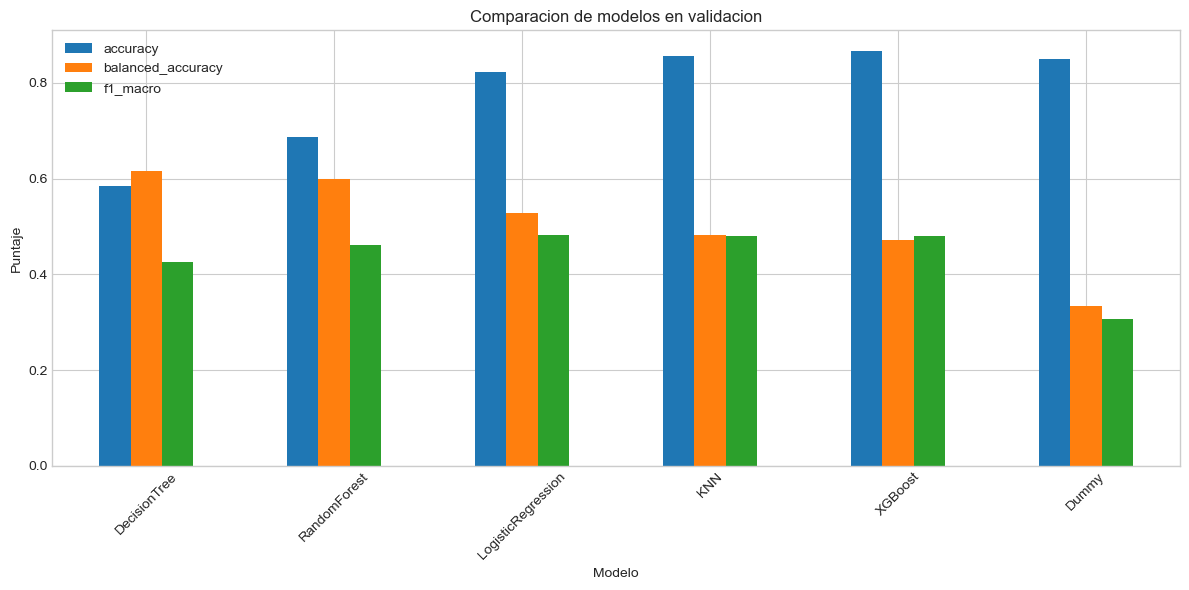

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
df_resultados_val.plot(
    x="modelo",
    y=["accuracy", "balanced_accuracy", "f1_macro"],
    kind="bar",
    ax=ax,
)
ax.set_title("Comparacion de modelos en validacion")
ax.set_ylabel("Puntaje")
ax.set_xlabel("Modelo")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(RUTA_GRAFICAS / "09_comparacion_modelos_validacion.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Elegir el mejor modelo y evaluarlo en test

Vamos a elegir el mejor modelo segun `balanced_accuracy` y luego lo probamos en el conjunto de test.

Este paso es importante porque una cosa es rendir bien en validacion y otra mantener ese rendimiento en datos mas recientes.

In [13]:
mejor_modelo_nombre = df_resultados_val.iloc[0]["modelo"]
mejor_modelo = modelos_entrenados[mejor_modelo_nombre]

pred_test = mejor_modelo.predict(X_test)
resultado_test = calcular_metricas(y_test, pred_test, mejor_modelo_nombre, "test")

print("Mejor modelo en validacion:", mejor_modelo_nombre)
display(pd.DataFrame([resultado_test]))


Mejor modelo en validacion: DecisionTree


,modelo,conjunto,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro
0,DecisionTree,test,0.586735,0.622654,0.472871,0.622654,0.419746


# confusion_matrix resume aciertos y errores por clase.
# ConfusionMatrixDisplay la dibuja de forma legible para interpretacion visual.

## 12. Matriz de confusion del mejor modelo

La matriz de confusion permite ver en que clases se equivoca el modelo.

Esto es muy util en problemas multiclase, especialmente porque la clase `Intermediate` tiene pocos casos.

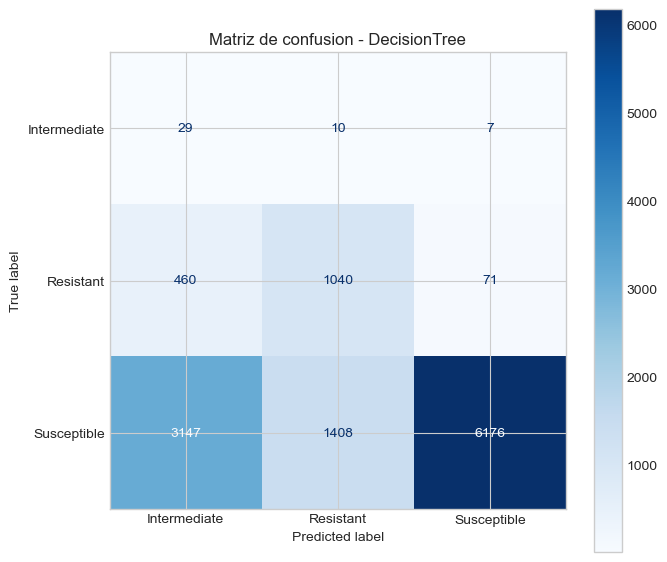

In [14]:
matriz = confusion_matrix(y_test, pred_test)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Matriz de confusion - {mejor_modelo_nombre}")
plt.tight_layout()
plt.savefig(RUTA_GRAFICAS / "10_matriz_confusion_mejor_modelo.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Guardar resultados

Aqui guardamos las metricas principales para usarlas luego en el informe o en comparaciones futuras.

In [15]:
# Guardamos los resultados con el nombre de la version del dataset para no sobreescribir archivos.
ruta_resultados_val = RUTA_MODELADO / f"resultados_validacion_modelos_{VERSION_DATASET}.csv"
ruta_resultado_test = RUTA_MODELADO / f"resultado_test_mejor_modelo_{VERSION_DATASET}.csv"

df_resultados_val.to_csv(ruta_resultados_val, index=False)
pd.DataFrame([resultado_test]).to_csv(ruta_resultado_test, index=False)

print("Archivos guardados:")
print(ruta_resultados_val)
print(ruta_resultado_test)


Archivos guardados:
D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\4.MODELADO-Y-VALIDACION\resultados_validacion_modelos_base.csv
D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\4.MODELADO-Y-VALIDACION\resultado_test_mejor_modelo_base.csv


## 14. Siguientes mejoras posibles

Despues de esta primera comparacion, las mejoras naturales serian:

- probar una segunda version incluyendo variables hoy excluidas
- corregir la logica de `prior_organism` desde el notebook anterior
- probar tecnicas de balanceo como `SMOTE`
- ajustar hiperparametros con una busqueda mas sistematica
- comparar train + validation contra test final una vez se elija el mejor enfoque

Primero hay que mirar los resultados reales de este notebook. Con esos resultados se decide si conviene refinar `KNN`, `RandomForest`, `XGBoost` o incluso descartar algunos.